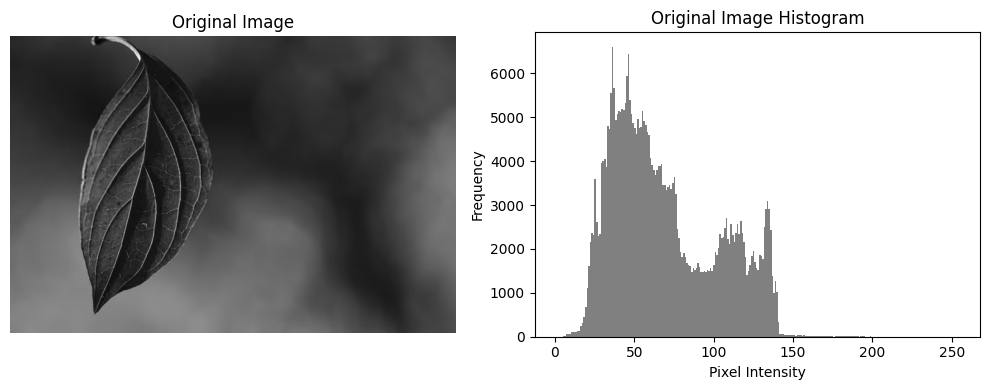

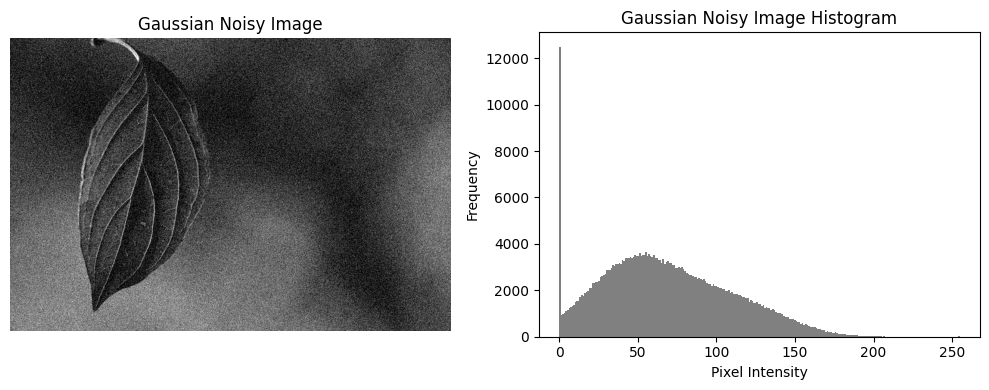

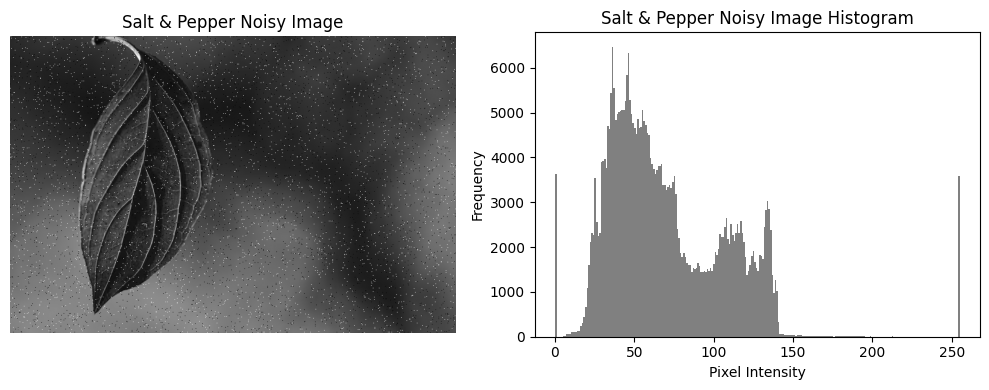

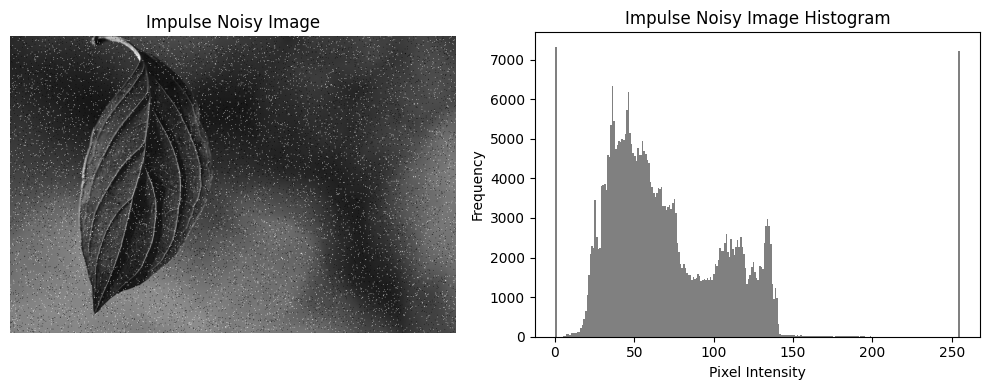

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load Image

image_path = "/content/leaf.jpg"  # Replace with your image path
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise ValueError("Image not found!")


# Noise Functions

def add_gaussian_noise(image, mean=0, sigma=25):
    gauss = np.random.normal(mean, sigma, image.shape)
    noisy = image.astype(np.float32) + gauss
    return np.clip(noisy, 0, 255).astype(np.uint8)

def add_salt_pepper_noise(image, salt_prob=0.01, pepper_prob=0.01):
    noisy = image.copy()
    total_pixels = image.size
    # Salt
    num_salt = int(salt_prob * total_pixels)
    coords = [np.random.randint(0, i, num_salt) for i in image.shape]
    noisy[coords[0], coords[1]] = 255
    # Pepper
    num_pepper = int(pepper_prob * total_pixels)
    coords = [np.random.randint(0, i, num_pepper) for i in image.shape]
    noisy[coords[0], coords[1]] = 0
    return noisy

def add_impulse_noise(image, prob=0.02):
    noisy = image.copy()
    rand = np.random.rand(*image.shape)
    noisy[rand < prob] = 0
    noisy[rand > 1 - prob] = 255
    return noisy

#apply noise
gaussian_img = add_gaussian_noise(img)
sp_img = add_salt_pepper_noise(img)
impulse_img = add_impulse_noise(img)

# Function to Display Image with Histogram

def display_image_histogram(image, title="Image"):
    plt.figure(figsize=(10,4))

    # Image
    plt.subplot(1,2,1)
    plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')

    # Histogram
    plt.subplot(1,2,2)
    plt.hist(image.ravel(), bins=256, range=(0,255), color='gray')
    plt.title(f"{title} Histogram")
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()


display_image_histogram(img, "Original Image")
display_image_histogram(gaussian_img, "Gaussian Noisy Image")
display_image_histogram(sp_img, "Salt & Pepper Noisy Image")
display_image_histogram(impulse_img, "Impulse Noisy Image")
